#### Inicializando

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
def autolabel(rects,ax):
    """Anexa uma etiqueta de texto acima de cada barra mostrando seu valor."""
    for rect in rects:
      height = rect.get_height()
      if abs(height) > 0:
        ax.annotate(f'R$ {height/1000000:,.2f} MM',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 pontos verticais de deslocamento
                    textcoords="offset points",
                    ha='center', va='bottom')

## Taxa Mínima de Atratividade – TMA

Para avaliarmos se a rentabilidade de um investimento (projetos, produtos financeiros, etc.) é bom ou ruim, é necessário compará-lo com alguma taxa de referência, que chamamos de taxa mínima de atratividade.

### Definição
É a menor taxa de juros que um investidor se propõe a ganhar, ponderado pelo risco do investimento.

### Exemplo para pessoas físicas

- Rentabilidade das opções de investimentos:
  - Poupança
  - CDI
  - Selic
- Taxa de retorno que sedeseja

Pessoas físicas sempre terão a opção de investir em produtos
financeiros de mercado.

Exemplo: Para retirar o capital da poupança para algum outro
produto financeiro, este último deverá resultar em um rendimento
maior que a da poupança para valer a pena.

### Exemplo para empresas

- Custo do seu capital (WACC – Weighted Average Cost of Capital)
- Taxa ajustada ao risco de um projeto

Uma empresa é composta por recursos próprios e/ou de terceiros, os quais exigem retornos específicos, que serão utilizados como referência para avaliação de qualquer investimento a ser realizado.

Exemplo: Um projeto com expectativa de retorno anual de 15% pode não ser aprovado se o custo médio ponderado de capital da empresa for de 17% a.a.

## Valor Presente de Fluxo de Caixa

No intuito de avaliar um investimento, devemos manipular o fluxo de caixa em períodos diferentes para um período especifico, podendo assim dimensionar sua atratividade.

###Exemplo
Após vender sua start-up para o Google por R$ 60 milhões, Lais gostaria de investir esse capital para obter uma renda passiva. O Investment Manager do Wealth Management do BNP Paribas solicitou a você avaliar se um título público (abaixo) é um bom investimento para Thomas. Atualmente todo o capital dele (Thomas) está na poupança (rentabilidade: 5% a.a.).

In [3]:
# Função para calcular o valor futuro
calc_valor_futuro = lambda principal,taxa_juros, periodo : principal * (1 + taxa_juros) ** periodo

$$ VP = \frac{VF_n}{(1+i)^n}$$

In [4]:
# Função para calcular o valor presente
calc_valor_presente = lambda valor_futuro,taxa_juros,periodo : valor_futuro / (1 + taxa_juros) ** periodo

In [5]:
# Parâmetros do investimento
capital_inicial = 60e6  # R$ 60 milhões
taxa_poupanca = 0.05  # 5% ao ano
entradas = [0, 6000000, 6000000, 6000000, 6000000, 66000000]
saidas = [-60000000, 0, 0, 0, 0, 0]

# Trazendo todos os valores ao presente
valor_presente = [calc_valor_presente(entradas[i], taxa_poupanca, i) for i in range(len(entradas))]

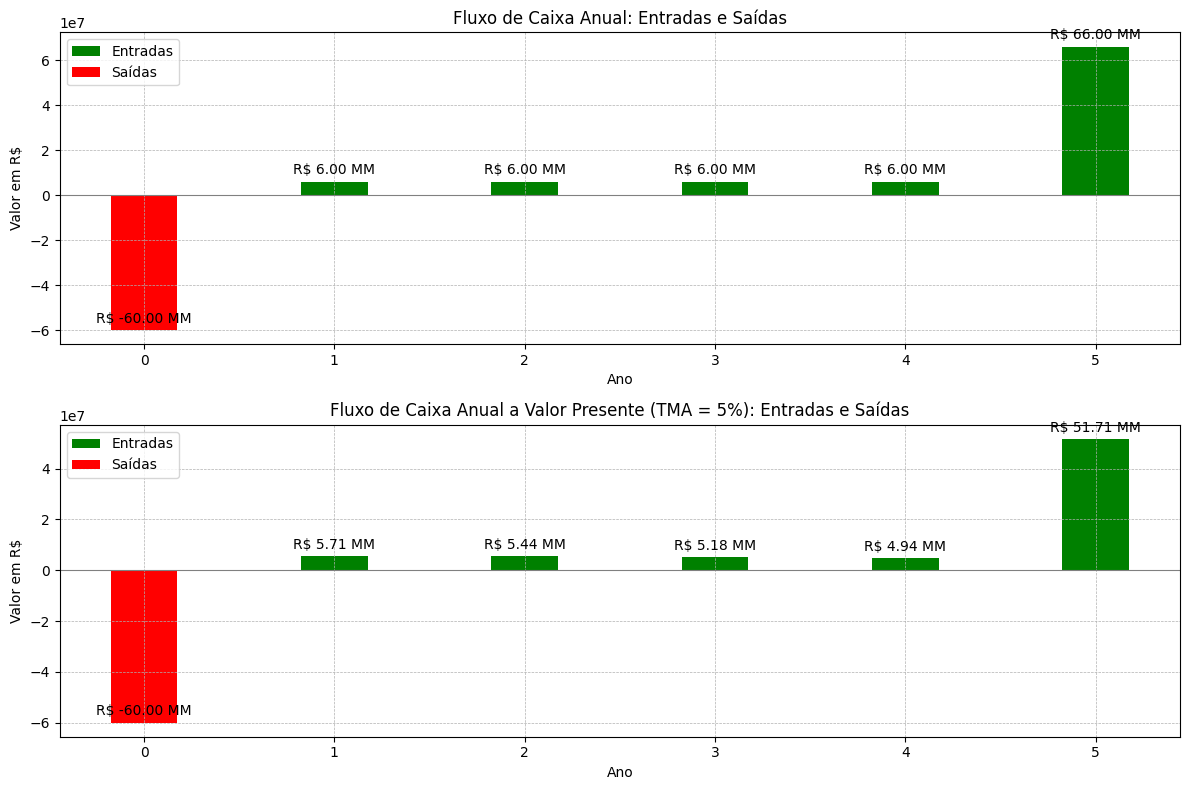

In [6]:
x = np.arange(len(entradas))  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

fig, ax = plt.subplots(2,1,figsize=(12, 8))
rects1 = ax[0].bar(x, entradas, largura, label='Entradas', color='green')
rects2 = ax[0].bar(x, saidas, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax[0].axhline(0, color='grey', linewidth=0.8)

autolabel(rects1,ax[0])
autolabel(rects2,ax[0])

# Configurações do gráfico
ax[0].set_title('Fluxo de Caixa Anual: Entradas e Saídas')
ax[0].set_ylabel('Valor em R$')
ax[0].set_xlabel('Ano')
ax[0].set_xticks(x)
ax[0].legend()
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)

rects3 = ax[1].bar(x, valor_presente, largura, label='Entradas', color='green')
rects4 = ax[1].bar(x, saidas, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax[1].axhline(0, color='grey', linewidth=0.8)

autolabel(rects3,ax[1])
autolabel(rects4,ax[1])

# Configurações do gráfico
ax[1].set_title('Fluxo de Caixa Anual a Valor Presente (TMA = 5%): Entradas e Saídas')
ax[1].set_ylabel('Valor em R$')
ax[1].set_xlabel('Ano')
ax[1].set_xticks(x)
ax[1].legend()
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [7]:
valor_total = (np.sum(valor_presente) - capital_inicial) / 1000000
print(f'Somando todos os valores que estão a valor presente, temos R$ {valor_total:,.2f} MM. \nSignifica que se Lais trocar a poupança por esse título, hoje ele ganharia R$ {valor_total:,.2f} MM')

Somando todos os valores que estão a valor presente, temos R$ 12.99 MM. 
Significa que se Lais trocar a poupança por esse título, hoje ele ganharia R$ 12.99 MM


### Explicando melhor

O método anterior, é uma forma simplficada de trazermos a valor presente a diferença entre o fluxo de caixa dos dois investimentos.

In [8]:
valor_futuro_poupanca = capital_inicial*(1+taxa_poupanca)**5
fluxo_caixa_poupanca = [-capital_inicial, 0, 0, 0, 0, valor_futuro_poupanca]

In [9]:
fluxo_caixa_titulo = np.array(entradas) + np.array(saidas)
diferenca_fcs = fluxo_caixa_titulo - np.array(fluxo_caixa_poupanca)

In [10]:
# Trazendo todos os valores ao presente
vp_diferenca_fcs = [calc_valor_presente(diferenca_fcs[i], taxa_poupanca, i) for i in range(len(entradas))]
vpl_final = np.sum(vp_diferenca_fcs) / 1e6
print(f'Somando todos os valores que estão a valor presente, temos R$ {vpl_final:,.2f} MM. \nSignifica que se Lais trocar a poupança por esse título, hoje ele ganharia R$ {vpl_final:,.2f} MM')


Somando todos os valores que estão a valor presente, temos R$ 12.99 MM. 
Significa que se Lais trocar a poupança por esse título, hoje ele ganharia R$ 12.99 MM


### Lidando com fluxos de caixa

Existem diversas formas de trabalhar com fluxos de caixa.

### Exemplo 1
O Diretor Financeiro renegociou uma dívida para 2024 em 10 parcelas iguais de R$ 10 milhões, sendo que no sexto mês não haverá pagamento, pois é o mês de maiores saídas de caixa da empresa. Calcule o PV do pagamento dessa dívida sabendo que o custo de capital da empresa é de 1,0% a.m..

In [11]:
# Parâmetros do investimento
capital_inicial = 60e6  # R$ 60 milhões
taxa_juros = 0.01  # 5% ao ano
entradas = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
saidas = [0, -10000000, -10000000, -10000000, -10000000, -10000000, 0, -10000000, -10000000, -10000000, -10000000, -10000000]

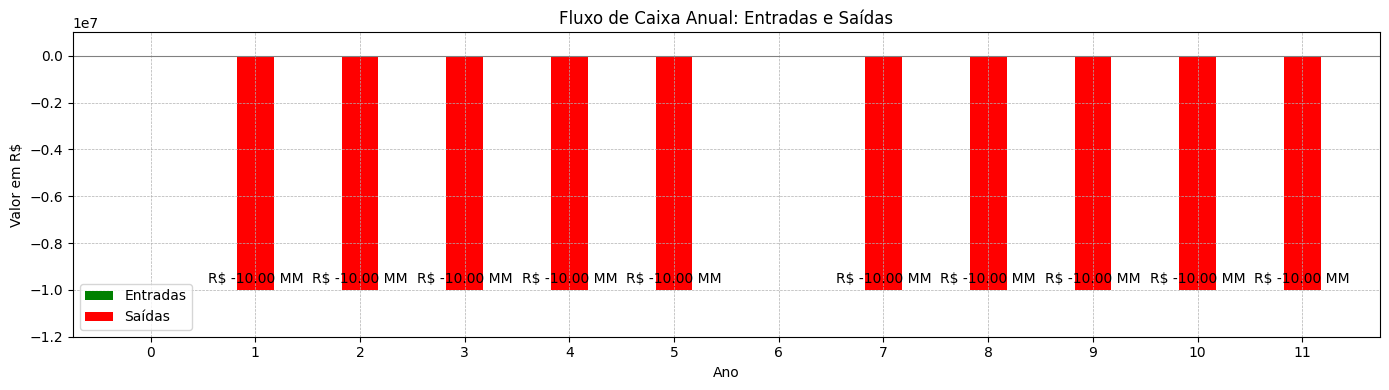

In [12]:
x = np.arange(len(entradas))  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

fig, ax = plt.subplots(1,1,figsize=(14, 4))
rects1 = ax.bar(x, entradas, largura, label='Entradas', color='green')
rects2 = ax.bar(x, saidas, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax.axhline(0, color='grey', linewidth=0.8)

autolabel(rects1,ax)
autolabel(rects2,ax)

# Configurações do gráfico
ax.set_title('Fluxo de Caixa Anual: Entradas e Saídas')
ax.set_ylabel('Valor em R$')
ax.set_xlabel('Ano')
ax.set_xticks(x)
ax.set_ylim(-12e6, 1e6)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

#### Solução 1

In [13]:
# Trazendo a primeira parte dos valores ao presente
parte_1 = saidas[:6]
valor_presente_1 = [calc_valor_presente(parte_1[i], taxa_juros, i) for i in range(len(parte_1))]
vpl_1 = np.sum(valor_presente_1)
print(f'Somando os valores que estão a valor presente, temos R$ {vpl_1 / 1e6:,.2f} MM.')

Somando os valores que estão a valor presente, temos R$ -48.53 MM.


In [14]:
# Trazendo a segunda parte os valores ao futuro
parte_2 = saidas[7:]
valor_futuro = [calc_valor_futuro(parte_2[i], taxa_juros, i) for i in range(len(parte_2))]

vfl = np.sum(valor_futuro)
print(f'Somando os valores que estão a valor futuro, temos R$ {vfl / 1e6:,.2f} MM.')

Somando os valores que estão a valor futuro, temos R$ -51.01 MM.


In [15]:
vpl_2 = calc_valor_presente(vfl,taxa_juros,11)
print(f'Agora, trazendo o volor futuro a valor presente, temos R$ {vpl_2 / 1e6:,.2f} MM.')

Agora, trazendo o volor futuro a valor presente, temos R$ -45.72 MM.


$$ VP_{total} = VP^{'} + VP^{''}$$

In [16]:
vpl_final = vpl_1 + vpl_2
print(f'Por fim, podemos somar ambos os valores e temos R$ {vpl_final / 1e6:,.2f} MM.')

Por fim, podemos somar ambos os valores e temos R$ -94.26 MM.


#### Solução 2

In [17]:
fluxo_alterado = saidas
fluxo_alterado[6] = fluxo_alterado[5]

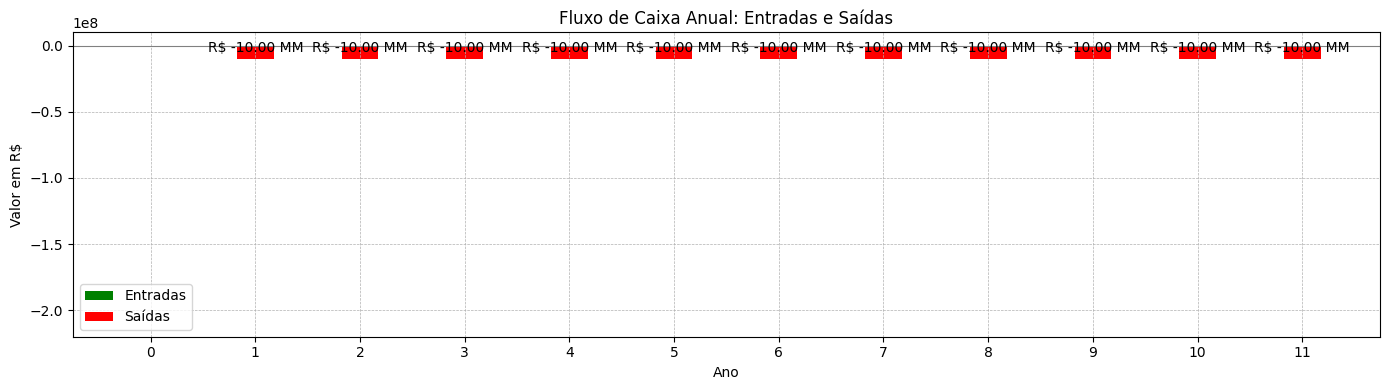

In [18]:
x = np.arange(len(entradas))  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

fig, ax = plt.subplots(1,1,figsize=(14, 4))
rects1 = ax.bar(x, entradas, largura, label='Entradas', color='green')
rects2 = ax.bar(x, saidas, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax.axhline(0, color='grey', linewidth=0.8)

autolabel(rects1,ax)
autolabel(rects2,ax)

# Configurações do gráfico
ax.set_title('Fluxo de Caixa Anual: Entradas e Saídas')
ax.set_ylabel('Valor em R$')
ax.set_xlabel('Ano')
ax.set_xticks(x)
ax.set_ylim(-22e7, 1e7)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [19]:
# Trazendo a primeira parte dos valores ao presente
valor_presente_alt = [calc_valor_presente(fluxo_alterado[i], taxa_juros, i) for i in range(len(fluxo_alterado))]
vpl_alt = np.sum(valor_presente_alt)
print(f'Somando todos os valores que estão a valor presente, temos R$ {vpl_alt / 1e6:,.2f} MM.')

Somando todos os valores que estão a valor presente, temos R$ -103.68 MM.


In [20]:
vpl_faltante = calc_valor_presente(fluxo_alterado[6],taxa_juros,6)
print(f'Agora, trazemos o valor adicionado a valor presente, temos R$ {vpl_faltante / 1e6:,.2f} MM.')

Agora, trazemos o valor adicionado a valor presente, temos R$ -9.42 MM.


$$ VP_{total} = VP^{'} + VP^{''}$$

In [21]:
vpl_final_alt = vpl_alt - vpl_faltante
print(f'Por fim, podemos subtrair ambos os valores e temos R$ R$ {vpl_final_alt / 1e6:,.2f} MM como valor final.')

Por fim, podemos subtrair ambos os valores e temos R$ R$ -94.26 MM como valor final.


### Exemplo 2
O Diretor Financeiro renegociou uma dívida para 2024 em 3 parcelas iguais de R\$ 200 mil nos primeiros 3 meses e 3 parcelas iguais de R\$ 100 mil nos próximos 3 meses. Calcule o PV do pagamento dessa dívida sabendo que o custo de capital da empresa é de 1,0% a,m..

In [22]:
# Parâmetros do investimento
capital_inicial = 60e6  # R$ 60 milhões
taxa_juros = 0.01  # 1% ao mês
entradas = [0, 0, 0, 0, 0, 0, 0]
saidas = [0, -200e6, -200e6, -200e6, -100e6, -100e6, -100e6]

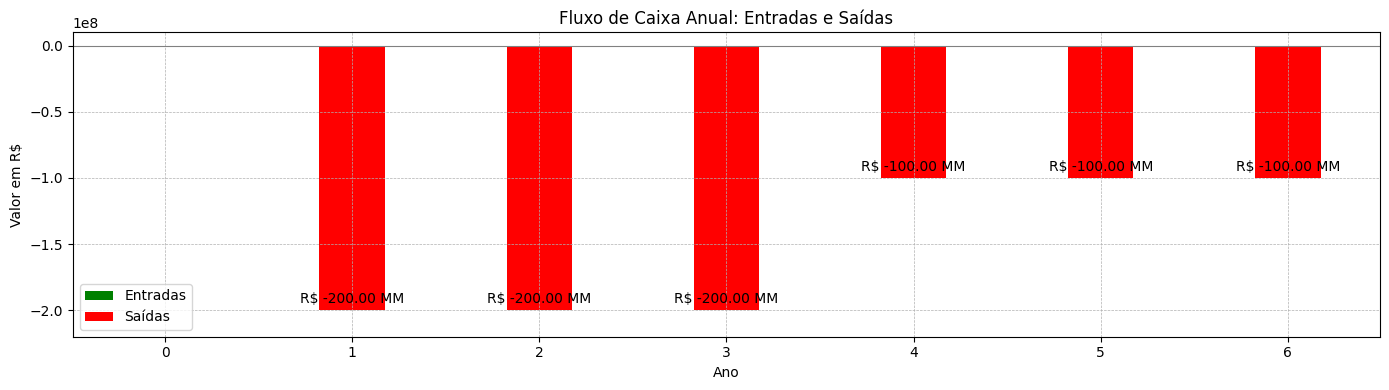

In [23]:
x = np.arange(len(entradas))  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

fig, ax = plt.subplots(1,1,figsize=(14, 4))
rects1 = ax.bar(x, entradas, largura, label='Entradas', color='green')
rects2 = ax.bar(x, saidas, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax.axhline(0, color='grey', linewidth=0.8)

autolabel(rects1,ax)
autolabel(rects2,ax)

# Configurações do gráfico
ax.set_title('Fluxo de Caixa Anual: Entradas e Saídas')
ax.set_ylabel('Valor em R$')
ax.set_xlabel('Ano')
ax.set_xticks(x)
ax.set_ylim(-22e7, 1e7)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

Primeiramente, separamos o fluxo de caixa em dois:

In [24]:
saidas_a = [*[saidas[0]] , *[i - (-100e6) for i in saidas[1:]]]

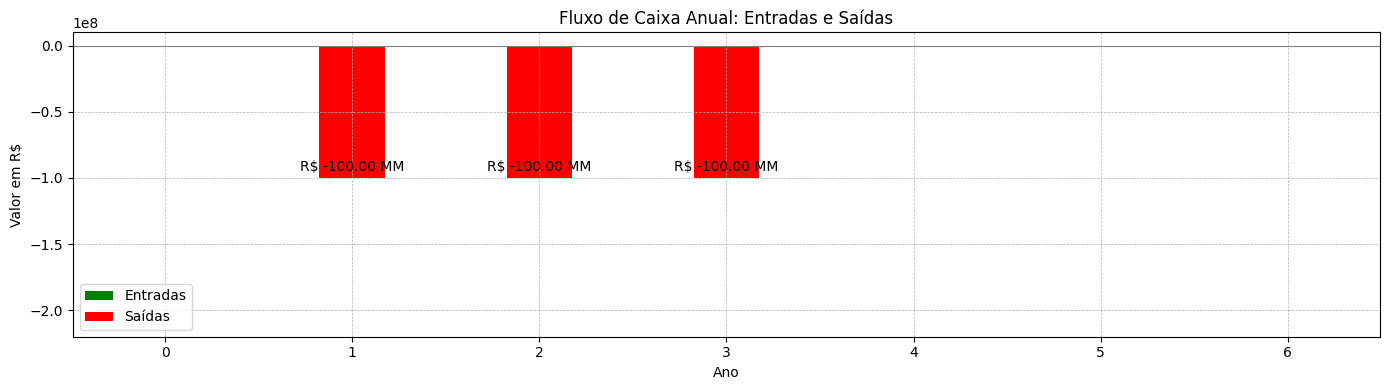

In [25]:
x = np.arange(len(entradas))  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

fig, ax = plt.subplots(1,1,figsize=(14, 4))
rects1 = ax.bar(x, entradas, largura, label='Entradas', color='green')
rects2 = ax.bar(x, saidas_a, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax.axhline(0, color='grey', linewidth=0.8)

autolabel(rects1,ax)
autolabel(rects2,ax)

# Configurações do gráfico
ax.set_title('Fluxo de Caixa Anual: Entradas e Saídas')
ax.set_ylabel('Valor em R$')
ax.set_xlabel('Ano')
ax.set_xticks(x)
ax.set_ylim(-22e7, 1e7)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [26]:
# Trazendo a primeira parte dos valores ao presente
valor_presente_a = [calc_valor_presente(saidas_a[i], taxa_juros, i) for i in range(len(saidas_a[:4]))]
vpl_a = np.sum(valor_presente_a)
print(f'Somando os valores que estão a valor presente no fluxo A, temos R$ {vpl_a / 1e6:,.2f} MM.')

Somando os valores que estão a valor presente no fluxo A, temos R$ -294.10 MM.


In [27]:
saidas_b = [*[saidas[0]] , *[-100e6 for i in saidas[1:]]]

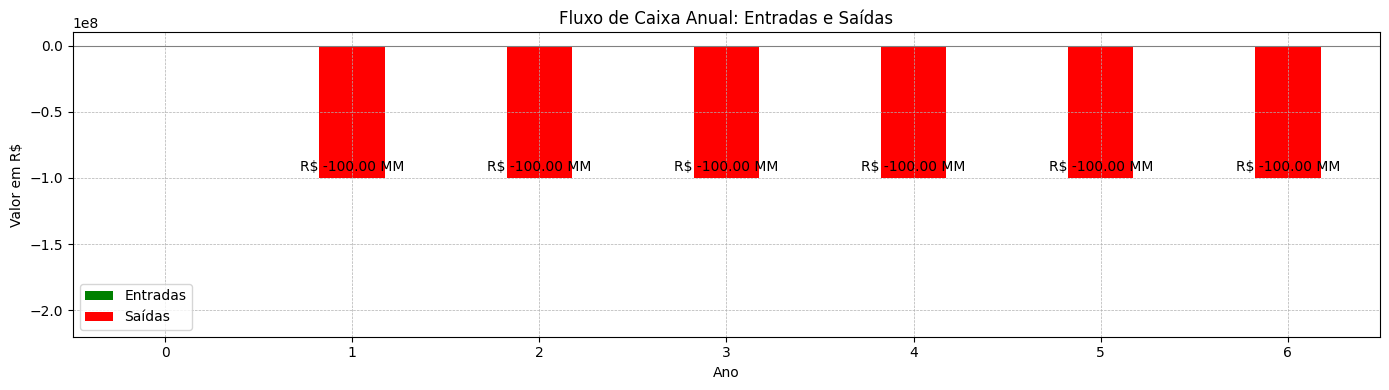

In [28]:
x = np.arange(len(entradas))  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

fig, ax = plt.subplots(1,1,figsize=(14, 4))
rects1 = ax.bar(x, entradas, largura, label='Entradas', color='green')
rects2 = ax.bar(x, saidas_b, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax.axhline(0, color='grey', linewidth=0.8)

autolabel(rects1,ax)
autolabel(rects2,ax)

# Configurações do gráfico
ax.set_title('Fluxo de Caixa Anual: Entradas e Saídas')
ax.set_ylabel('Valor em R$')
ax.set_xlabel('Ano')
ax.set_xticks(x)
ax.set_ylim(-22e7, 1e7)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [29]:
# Trazendo a primeira parte dos valores ao presente
valor_presente_b = [calc_valor_presente(saidas_b[i], taxa_juros, i) for i in range(len(saidas_b))]
vpl_b = np.sum(valor_presente_b)
print(f'Somando os valores que estão a valor presente no fluxo B, temos R$ {vpl_b / 1e6:,.2f} MM.')

Somando os valores que estão a valor presente no fluxo B, temos R$ -579.55 MM.


$$ VP_{total} = VP^{'} + VP^{''}$$

In [30]:
vpl_total = vpl_a + vpl_b
print(f'Por fim, podemos subtrair ambos os valores e temos R$ R$ {vpl_total / 1e6:,.2f} MM como valor final.')

Por fim, podemos subtrair ambos os valores e temos R$ R$ -873.65 MM como valor final.


## Valor Presente de Fluxo de Caixa não-homogêneo

O fluxo de caixa não-homogêneo é aquele cujos valores são distintos entre si e que não apresentam nenhuma lei de formação que permita uma simplificação do cálculo do valor presente líquido pelo uso da função PMT.

### Exemplo
Dado a tabela com o fluxo de caixa abaixo, calcular o valor presente, descontando a uma taxa de 10% a.a..

In [31]:
# Parâmetros do investimento
taxa_juros = 0.1  # 10% ao ano
entradas = [0, 2350e3, 1390e3, 3350e3, 4275e3, 5350e3]
saidas = [0, 0, 0, 0, 0, 0]

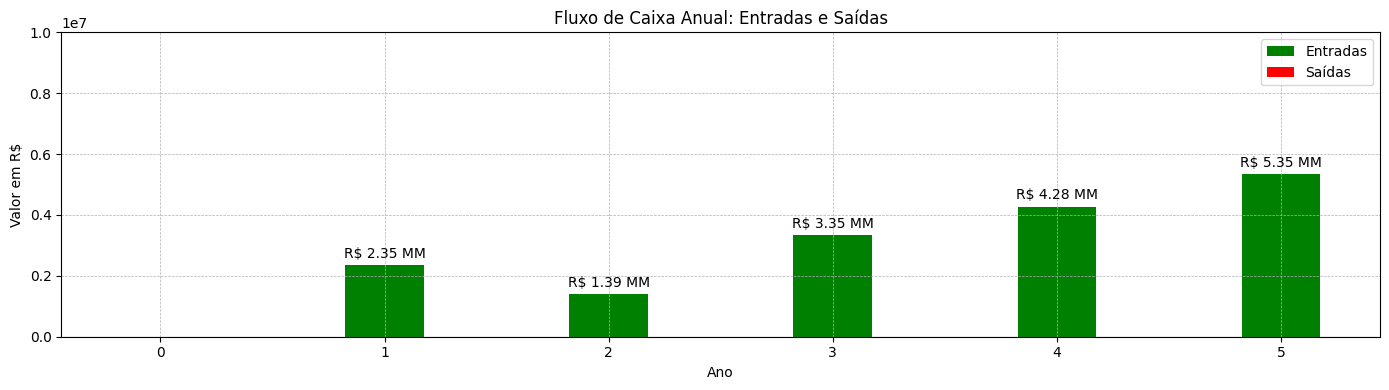

In [32]:
x = np.arange(len(entradas))  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

fig, ax = plt.subplots(1,1,figsize=(14, 4))
rects1 = ax.bar(x, entradas, largura, label='Entradas', color='green')
rects2 = ax.bar(x, saidas, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax.axhline(0, color='grey', linewidth=0.8)

autolabel(rects1,ax)
autolabel(rects2,ax)

# Configurações do gráfico
ax.set_title('Fluxo de Caixa Anual: Entradas e Saídas')
ax.set_ylabel('Valor em R$')
ax.set_xlabel('Ano')
ax.set_xticks(x)
ax.set_ylim(0, 1e7)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

O fluxo de caixa é totalmente heterogêneo, não permitindo qualquer simplificação algébrica. Assim, a única maneira de se obter seu valor presente é mediante o desconto individual de cada uma de suas parcelas.

In [33]:
# Trazendo cada ano aos seus respectivos valores presente
valor_presente_nh = [calc_valor_presente(entradas[i], taxa_juros, i) for i in range(len(entradas))]

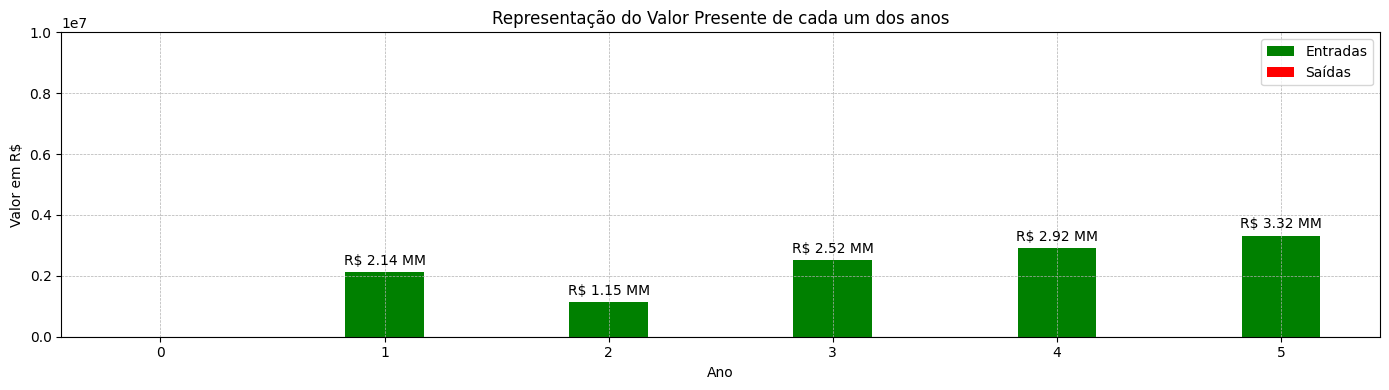

In [34]:
x = np.arange(len(valor_presente_nh))  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

fig, ax = plt.subplots(1,1,figsize=(14, 4))
rects1 = ax.bar(x, valor_presente_nh, largura, label='Entradas', color='green')
rects2 = ax.bar(x, saidas, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax.axhline(0, color='grey', linewidth=0.8)

autolabel(rects1,ax)
autolabel(rects2,ax)

# Configurações do gráfico
ax.set_title('Representação do Valor Presente de cada um dos anos')
ax.set_ylabel('Valor em R$')
ax.set_xlabel('Ano')
ax.set_xticks(x)
ax.set_ylim(0, 1e7)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [35]:
vpl_nh = np.sum(valor_presente_nh)
print(f'Somando os valores que estão a valor presente no fluxo de caixa, temos R$ {vpl_nh/1e6:,.2f} MM.')

Somando os valores que estão a valor presente no fluxo de caixa, temos R$ 12.04 MM.


## Valor Presente de Fluxo de Caixa e o Valor Presente Líquido (VPL ou NPV)

Somando o valor presente do fluxo de caixa com o valor do período 0 obtemos o Valor Presente Líquido (VPL ou NPV).

### VPL
- É igual ao valor presente de suas parcelas futuras (que são descontadas a uma determinada taxa de
desconto), somado algebricamente com a grandeza colocada no ponto zero.
- Normalmente, a grandeza colocada no ponto zero corresponde ao investimento inicial (saída de caixa).

$$
  VPL = FC_0 + \sum{ \frac{ FC_t }{ (1+i)^t } }
$$

### Exemplo
Um fundo imobiliário garante que, caso seja investido R\$ 100 mil hoje, será possível resgatar R\$ 121 mil em 2 anos. Este investimento vale a pena? Taxa básica de juros = 8% a.a.

In [36]:
taxa_juros = .08
capital_investido = 100e3
resgate = 121e3
fluxo_de_caixa = [-capital_investido, 0, resgate]
fluxo_taxa_mercado = [-capital_investido, 0, calc_valor_futuro(capital_investido,taxa_juros,2)]

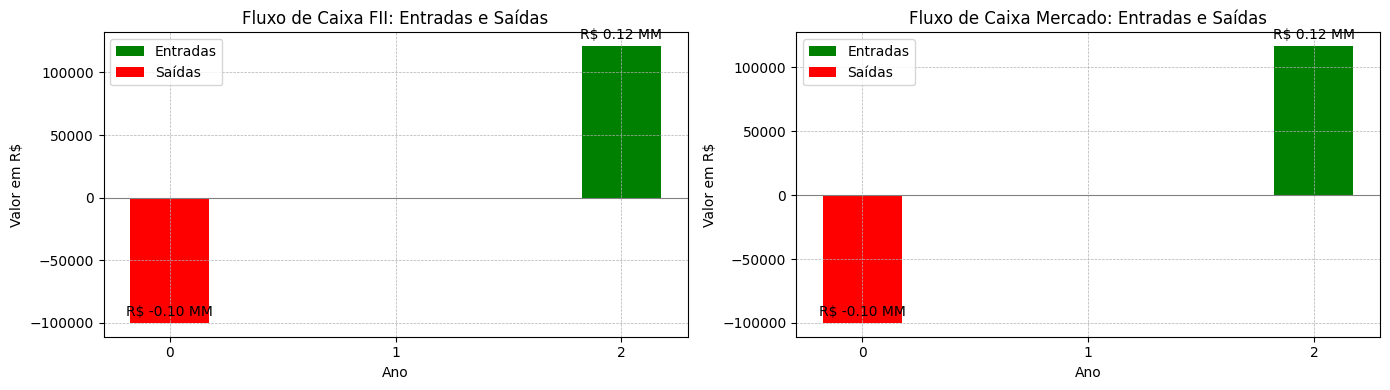

In [41]:
x = np.arange(len(fluxo_de_caixa))  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

entradas = [x if x >= 0 else 0 for x in fluxo_de_caixa]
saidas = [x if x < 0 else 0 for x in fluxo_de_caixa]

fig, ax = plt.subplots(1,2,figsize=(14, 4))
rects1 = ax[0].bar(x, entradas, largura, label='Entradas', color='green')
rects2 = ax[0].bar(x, saidas, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax[0].axhline(0, color='grey', linewidth=0.8)

autolabel(rects1,ax[0])
autolabel(rects2,ax[0])

# Configurações do gráfico
ax[0].set_title('Fluxo de Caixa FII: Entradas e Saídas')
ax[0].set_ylabel('Valor em R$')
ax[0].set_xlabel('Ano')
ax[0].set_xticks(x)
ax[0].legend()
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)

entradas = [x if x >= 0 else 0 for x in fluxo_taxa_mercado]
saidas = [x if x < 0 else 0 for x in fluxo_taxa_mercado]

rects3 = ax[1].bar(x, entradas, largura, label='Entradas', color='green')
rects4 = ax[1].bar(x, saidas, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax[1].axhline(0, color='grey', linewidth=0.8)

autolabel(rects3,ax[1])
autolabel(rects4,ax[1])

# Configurações do gráfico
ax[1].set_title('Fluxo de Caixa Mercado: Entradas e Saídas')
ax[1].set_ylabel('Valor em R$')
ax[1].set_xlabel('Ano')
ax[1].set_xticks(x)
ax[1].legend()
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

$$
VPL_{8\%} = VP(121.000) + VP(-100.000)
$$

In [42]:
vpl_investimento_08 = calc_valor_presente(resgate,taxa_juros,2) + calc_valor_presente(-capital_investido,taxa_juros,0)
print(f'Calculando o valor presente líquido em uma taxa de juros de 8% ao ano, chegamos a R$ {vpl_investimento_08:,.2f}.')

Calculando o valor presente líquido em uma taxa de juros de 8% ao ano, chegamos a R$ 3,738.00.


In [43]:
#validando resultado
calc_valor_futuro(vpl_investimento_08,taxa_juros,2), fluxo_de_caixa[2] - fluxo_taxa_mercado[2]

(4359.99999999999, 4359.999999999985)

## VPL de um fluxo de caixa perpétuo

Perpetuidade pode ser entendido como um valor que se repete indefinidamente em intervalos regulares. Pode ser um valor fixo (perpetuidade sem crescimento) ou um valor com crescimento constante (perpetuidade com crescimento).

### Exemplo 1 (Sem crescimento)
Um gestor de renda fixa avalia alocar R\$ 10 milhões em uma debênture perpétua que pagará R\$ 1 milhão por ano para sempre. Sabendo que o custo de capital do banco é de 12% a.a., esse investimento vale a pena?

Quando o valor é constante:
$$
  VP = \frac{FC_1}{i}
$$

In [44]:
taxa_juros = .12
capital_investido = 10e6
pagamento = 1e6

In [45]:
fluxo_de_caixa = [-capital_investido] + [pagamento for x in range(10)]

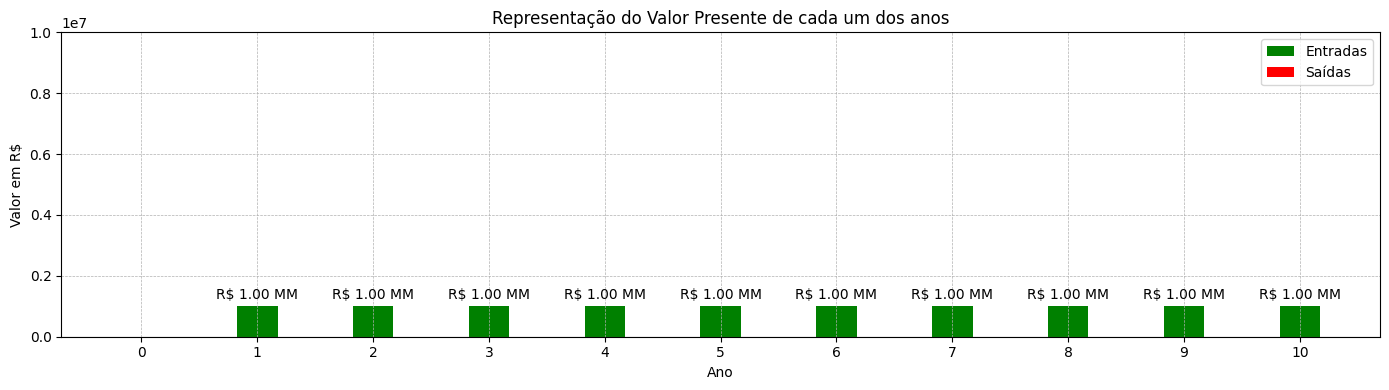

In [66]:
x = np.arange(len(fluxo_de_caixa))  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

entradas = [x if x >= 0 else 0 for x in fluxo_de_caixa]
saidas = [x if x < 0 else 0 for x in fluxo_de_caixa]

fig, ax = plt.subplots(1,1,figsize=(14, 4))
rects1 = ax.bar(x, entradas, largura, label='Entradas', color='green')
rects2 = ax.bar(x, saidas, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax.axhline(0, color='grey', linewidth=0.8)

autolabel(rects1,ax)
autolabel(rects2,ax)

# Configurações do gráfico
ax.set_title('Representação do Valor Presente de cada um dos anos')
ax.set_ylabel('Valor em R$')
ax.set_xlabel('Ano')
ax.set_xticks(x)
ax.set_ylim(0, 1e7)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [103]:
vp_fc_perpetuo = pagamento / taxa_juros
print(f'Calculando o valor presente do fluxo de caixa, em uma taxa de juros de {taxa_juros*100}% ao ano, chegamos a R$ {vp_fc_perpetuo/1e6:,.2f} MM.')

Calculando o valor presente do fluxo de caixa, em uma taxa de juros de 12.0% ao ano, chegamos a R$ 8.33 MM.


In [73]:
if(vp_fc_perpetuo - capital_investido > 0):
  print('O investimento vale a pena.')
else:
  print('O investimento não vale a pena.')

O investimento não vale a pena.


### Exemplo 2 (Com crescimento)
Um gestor de renda fixa avalia alocar R\$ 10 milhões em uma debênture perpétua que pagará R\$ 1 milhão anualmente, com crescimento de 4% nesse valor a cada ano. Sabendo que o custo de capital do banco é de 12% a.a., esse investimento vale a pena?

Quando o valor é crescente:
$$
  VP = \frac{FC_1}{i-g}
$$

In [82]:
crescimento = .04
taxa_juros = .12
capital_investido = 10e6
pagamento = 1e6

In [96]:
valor_acumulado = pagamento
pagamentos = [pagamento]

for i in range(1, 10):
  pagamentos.append(pagamentos[i-1] + valor_acumulado * crescimento)
  valor_acumulado = valor_acumulado * (1 + crescimento)

In [97]:
fluxo_de_caixa = [-capital_investido] + pagamentos

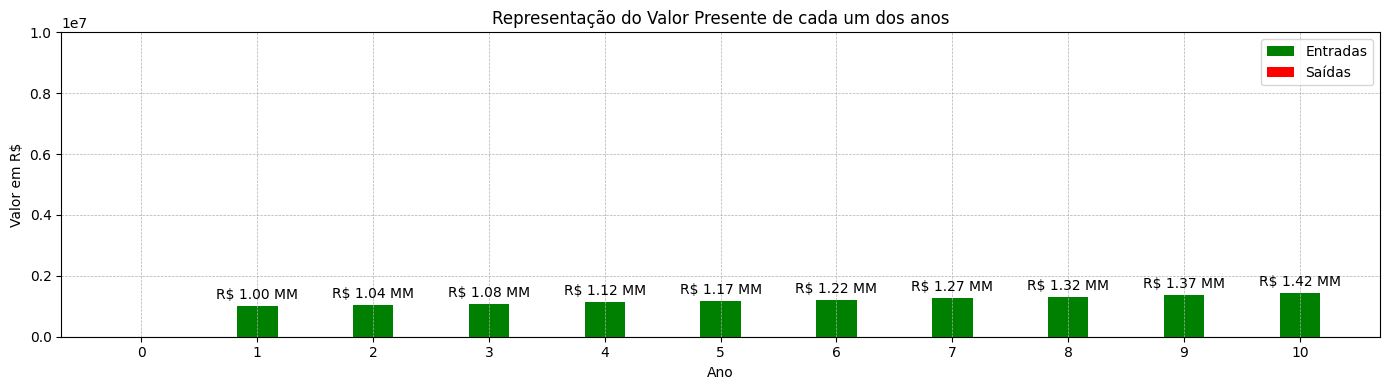

In [98]:
x = np.arange(len(fluxo_de_caixa))  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

entradas = [x if x >= 0 else 0 for x in fluxo_de_caixa]
saidas = [x if x < 0 else 0 for x in fluxo_de_caixa]

fig, ax = plt.subplots(1,1,figsize=(14, 4))
rects1 = ax.bar(x, entradas, largura, label='Entradas', color='green')
rects2 = ax.bar(x, saidas, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax.axhline(0, color='grey', linewidth=0.8)

autolabel(rects1,ax)
autolabel(rects2,ax)

# Configurações do gráfico
ax.set_title('Representação do Valor Presente de cada um dos anos')
ax.set_ylabel('Valor em R$')
ax.set_xlabel('Ano')
ax.set_xticks(x)
ax.set_ylim(0, 1e7)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [108]:
vp_fc_perpetuo = pagamento / (taxa_juros - crescimento)
print(f'Calculando o valor presente do fluxo de caixa, em uma taxa de juros de {taxa_juros*100}% ao ano, chegamos a R$ {vp_fc_perpetuo/1e6:,.2f} MM.')

Calculando o valor presente do fluxo de caixa, em uma taxa de juros de 12.0% ao ano, chegamos a R$ 12.50 MM.


In [110]:
if(vp_fc_perpetuo - capital_investido > 0):
  print('O investimento vale a pena.')
else:
  print('O investimento não vale a pena.')

O investimento vale a pena.


## Exemplos: Bonds perpétuos

In [111]:
from IPython.display import IFrame

In [112]:
IFrame('https://www.bloomberg.com/news/articles/2022-11-09/why-perpetual-bonds-are-rocking-credit-markets-quicktake', width=700, height=350)

In [113]:
IFrame('https://www.business-standard.com/industry/banking/banks-urge-return-to-call-option-valuation-for-perpetual-bonds-report-124012500317_1.html', width=700, height=350)

## A Taxa Interna de Retorno - TIR (ou IRR – Internal Rate of Return)

A TIR – Taxa Interna de Retorno – é a taxa intrínseca a um fluxo de caixa dado. Se o fluxo for de investimento, a TIR será a rentabilidade deste projeto / investimento. Se o fluxo for de financiamento, a TIR será a taxa cobrada neste financiamento.

### TIR
- É a taxa de desconto que faz o VPL de um fluxo de caixa ser zero.
- O VPL de um fluxo de caixa é igual a zero quando as grandezas futuras, ao serem descontadas com uma determinada taxa, produzem um valor presente igual ao desembolso inicial.

### Exemplo
Um fundo imobiliário garante que, caso seja investido R\$ 100 mil hoje, será possível resgatar R\$ 121 mil em 2 anos. Este investimento vale a pena? Taxa básica de juros = 12% a.a.


In [114]:
taxa_juros = .12
capital_investido = 100e3
resgate = 121e3
fluxo_de_caixa = [-capital_investido, 0, resgate]
fluxo_taxa_mercado = [-capital_investido, 0, calc_valor_futuro(capital_investido,taxa_juros,2)]

$$
VPL_{12\%} = VP(121.000) + VP(-100.000)
$$

In [115]:
vpl_investimento_12 = calc_valor_presente(resgate, taxa_juros, 2) + calc_valor_presente(-capital_investido, taxa_juros, 0)
print(f'Calculando o valor presente líquido a uma taxa de jutos de 12% ao ano, chegamos a R$ {vpl_investimento_12:,.2f}.')

Calculando o valor presente líquido a uma taxa de jutos de 12% ao ano, chegamos a R$ -3,539.54.


In [116]:
print(f'Ou seja, a 8% temos {vpl_investimento_08:,.2f} e a 12% temos R$ {vpl_investimento_12:,.2f}.')

Ou seja, a 8% temos 3,738.00 e a 12% temos R$ -3,539.54.


Como a taxa interna de retorno é a taxa de desconto que anula o valor presente líquido, podemos concluir, com os resultados anteriores, que ela está compreendida entre 8%a.a. e 12%a.a..

Cada fluxo de caixa possui uma curva característica de VPL x Taxa de desconto.

In [117]:
vpl_exemplo = lambda vf,i,principal,p : calc_valor_presente(vf, i, p) + calc_valor_presente(-principal, i, 0)

In [118]:
vpls = [vpl_exemplo(resgate, i/100, capital_investido, 2) for i in range(20)]

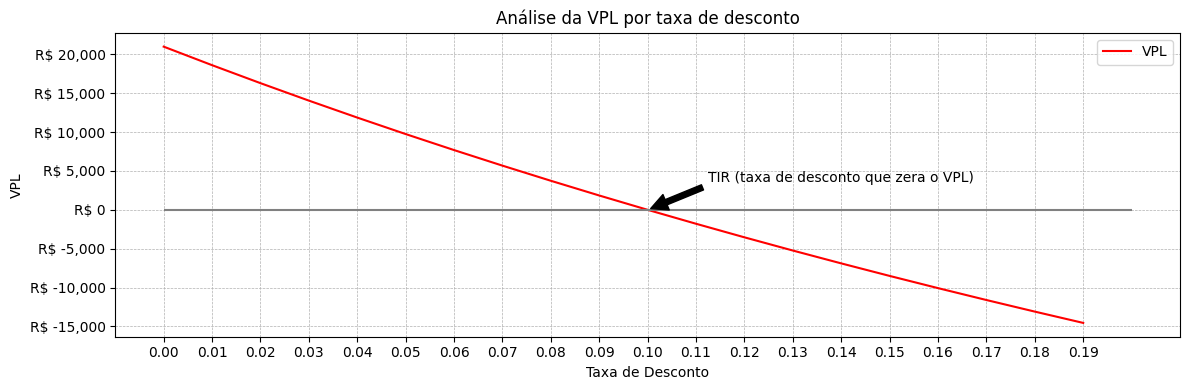

In [119]:
x = np.arange(20)/100  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

fig, ax = plt.subplots(1,1,figsize=(12, 4))
rects2 = ax.plot(x, vpls, label='VPL', color='red')
plt.hlines(y=0, xmin=0, xmax=.2, color = 'gray')

plt.annotate('TIR (taxa de desconto que zera o VPL)', xy=(.1, 0), xytext=(.14, 5000),
             arrowprops=dict(facecolor='black', shrink=0.05),
             horizontalalignment='center', verticalalignment='top')

# Configurações do gráfico
ax.set_title('Análise da VPL por taxa de desconto')
ax.set_ylabel('VPL')
ax.set_xlabel('Taxa de Desconto')
ax.set_xticks(x)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('R$ {x:,.0f}'))

plt.tight_layout()
plt.show()

In [120]:
taxa_juros = .1

In [121]:
vpl_investimento_10 = calc_valor_presente(resgate, taxa_juros, 2) + calc_valor_presente(-capital_investido, taxa_juros, 0)
print(f'Por fim, calculando o valor presente líquido a uma taxa de jutos de 10% ao ano, chegamos a R$ {vpl_investimento_10:,.2f}.')

Por fim, calculando o valor presente líquido a uma taxa de jutos de 10% ao ano, chegamos a R$ -0.00.


Portanto, para o fluxo de caixa fornecido pelo fundo imobiliário, a TIR (IRR – Internal Rate of Return) é i = 10% a.a..

O gráfico de financiamento (dívida) é simétrico ao gráfico do fluxo de caixa do investimento.

### Exemplo
Para financiar a expansão do parque produtivo da Suzano, seu CFO contratou uma dívida de R\$ 100 milhões com o JP Morgan com um prazo de amortização de 5 anos (15, 20, 30, 35, 45 milhões). O custo do capital próprio da empresa é de 12% a.a.. Neste cenário, vale a pena contrair a dívida ou usar capital próprio?

In [122]:
principal = 100e6
amortizacao = [-15e6, -20e6, -30e6, -35e6, -45e6]

In [123]:
vpl = lambda valores,i,principal,n : calc_valor_presente(principal, i, 0) + np.sum([calc_valor_presente(valores[p], i, p+1) for p in range(n)])

In [124]:
vpls = np.array([vpl(amortizacao, i/100, principal, 5) for i in range(20)])/1e6

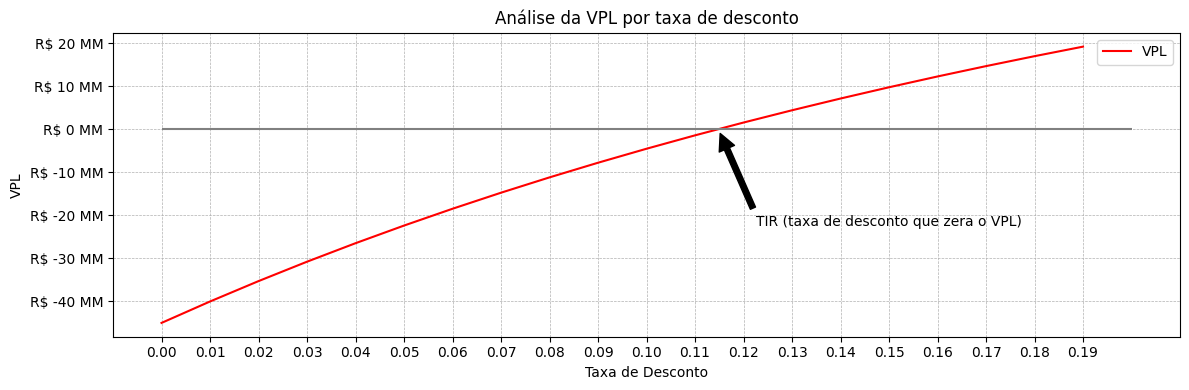

In [125]:
x = np.arange(20)/100  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

fig, ax = plt.subplots(1,1,figsize=(12, 4))
rects2 = ax.plot(x, vpls, label='VPL', color='red')
plt.hlines(y=0, xmin=0, xmax=.2, color = 'gray')

plt.annotate('TIR (taxa de desconto que zera o VPL)', xy=(.1148, 0), xytext=(.15, -20),
             arrowprops=dict(facecolor='black', shrink=0.05),
             horizontalalignment='center', verticalalignment='top')

# Configurações do gráfico
ax.set_title('Análise da VPL por taxa de desconto')
ax.set_ylabel('VPL')
ax.set_xlabel('Taxa de Desconto')
ax.set_xticks(x)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('R$ {x:,.0f} MM'))

plt.tight_layout()
plt.show()

## Payback Descontado (PBD)

### Definição
Tempo necessário para a recuperação do investimento inicial, levando-se em consideração o custo de oportunidade do capital investido.

É medido pelo tempo decorrido entre a data inicial do fluxo de caixa (ponto zero) e a data futura mais próxima até a qual o valor do investimento inicial é coberto pela soma dos valores presentes das parcelas positivas do fluxo de caixa.

Importante: Payback dá a dimensão do risco do investimento | Paybacks longos = Riscos mais altos <> Paybacks curtos = Riscos mais baixos

### Contexto
Você é consultor do BCG e está ajudando uma empresa de infraestrutura a decidir se um projeto é bom para a empresa. Ele (projeto) exigirá R\$ 100 milhões de investimentos e fornecerá um fluxo de caixa por 5 anos
conforme diagrama abaixo. A empresa apenas aprova projetos com paybacks menores que 4 anos (taxa de desconto = 10% ao ano).

In [126]:
capital_inicial = 100e6
fluxo_de_caixa = [-capital_inicial, 20e6, 30e6, 40e6, 50e6]

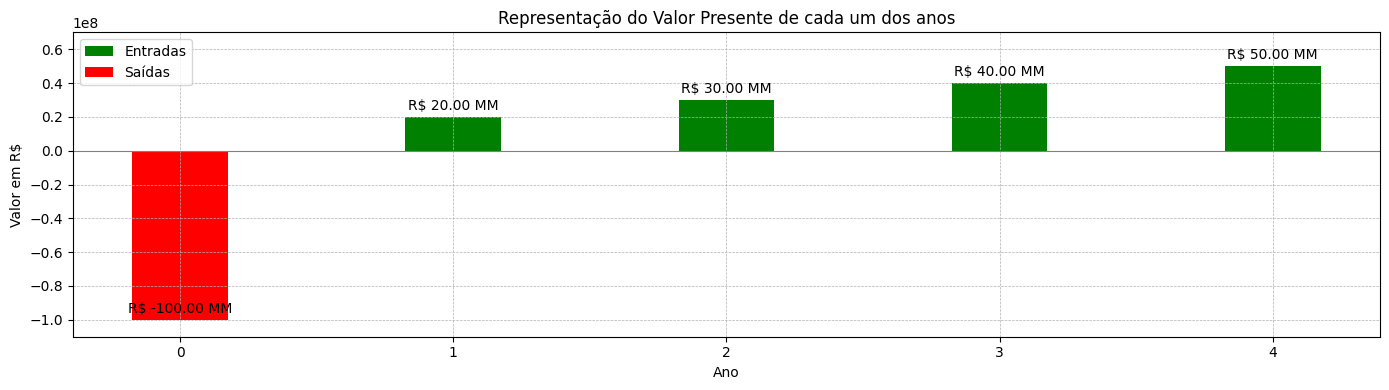

In [129]:
x = np.arange(len(fluxo_de_caixa))  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

entradas = [x if x >= 0 else 0 for x in fluxo_de_caixa]
saidas = [x if x < 0 else 0 for x in fluxo_de_caixa]

fig, ax = plt.subplots(1,1,figsize=(14, 4))
rects1 = ax.bar(x, entradas, largura, label='Entradas', color='green')
rects2 = ax.bar(x, saidas, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax.axhline(0, color='grey', linewidth=0.8)

autolabel(rects1,ax)
autolabel(rects2,ax)

# Configurações do gráfico
ax.set_title('Representação do Valor Presente de cada um dos anos')
ax.set_ylabel('Valor em R$')
ax.set_xlabel('Ano')
ax.set_xticks(x)
ax.set_ylim(-110e6, 70e6)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [131]:
fluxo_de_caixa_acc = np.cumsum(fluxo_de_caixa)

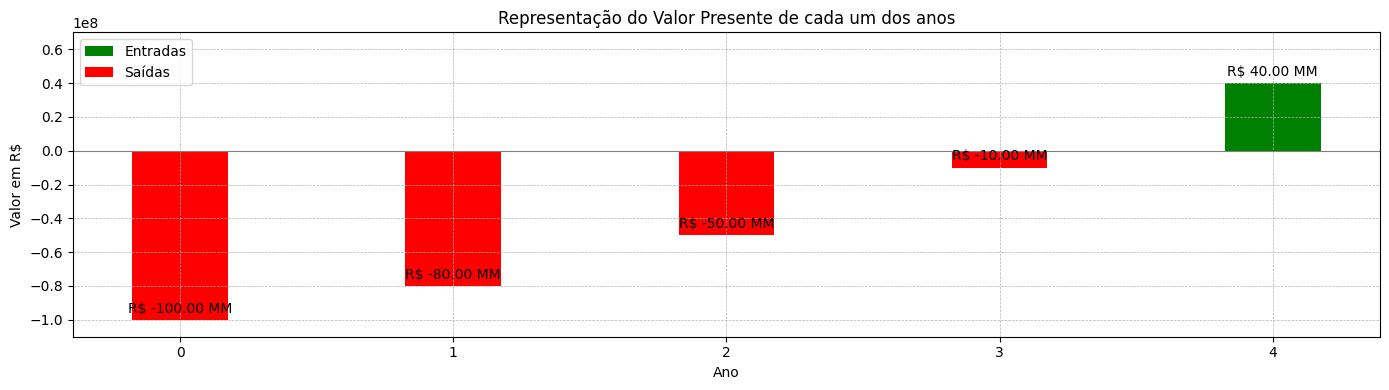

In [132]:
x = np.arange(len(fluxo_de_caixa_acc))  # Localização no eixo x para os grupos
largura = 0.35  # Largura das barras

entradas = [x if x >= 0 else 0 for x in fluxo_de_caixa_acc]
saidas = [x if x < 0 else 0 for x in fluxo_de_caixa_acc]

fig, ax = plt.subplots(1,1,figsize=(14, 4))
rects1 = ax.bar(x, entradas, largura, label='Entradas', color='green')
rects2 = ax.bar(x, saidas, largura, label='Saídas', color='red')

# Adicionar anotações no gráfico
ax.axhline(0, color='grey', linewidth=0.8)

autolabel(rects1,ax)
autolabel(rects2,ax)

# Configurações do gráfico
ax.set_title('Representação do Valor Presente de cada um dos anos')
ax.set_ylabel('Valor em R$')
ax.set_xlabel('Ano')
ax.set_xticks(x)
ax.set_ylim(-110e6, 70e6)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

Caso o Fluxo de Caixa seja discreto, ou seja, a entrada de caixa só acontece exatamente no fim de cada ano, o Payback deste fluxo é 4 anos.

Caso contrário, calculamos usando interpolação linear:
$$
  \frac{x-0}{365-0} = \frac{0-(-27)}{7,2-(-27)}
$$

In [137]:
x = 365*27/(7.2+27)
print(f'O Payback desse fluxo de caixa será {x:,.0f} dias.')

O Payback desse fluxo de caixa será 288 dias.


## Exercício

1. Uma empresa avalia o investimento de R\$ 1,1 milhão em um projeto de infraestrutura. Sabendo que o TMA da empresa é de 12,00% ao ano, calcule o NPV, IRR e Payback do projeto e avalie se o investimento pode ser aprovado.

2. Um determinado investimento tem um fluxo de caixa projetado conforme tabela abaixo. Após o 7o período o fluxo estabiliza e fica com o mesmo valor para sempre. Calcule o valor presente desse investimento sabendo que o TMA é de 12,00% ao ano.

3. Um determinado investimento tem um fluxo de caixa projetado conforme tabela abaixo. Após o 7o período o fluxo cresce a uma taxa de 3,0% ao ano para sempre. Calcule o valor presente desse investimento sabendo que o TMA é de 12,00% ao ano.

4. Uma empresa tem uma dívida de R\$ 1,5 milhão para saldar com um banco. Existem duas opções: (1) saldar a dívida à vista; (2) saldar a dívida em 10 parcelas de R\$ 180 mil, sendo a primeira parcela à vista e as demais mensalmente; Caso o diretor financeiro opte pela opção (2), quais os juros embutidos nessa opção?